# MET4A pickle-to-recarray demonstration

This notebook demonstrates how to use `src/met4a.py` with the pickle files in `2026_02_12`.

It shows:
- Loading and inspecting one pickle dictionary
- Converting one dictionary into a NumPy recarray
- Loading every pickle into one chronological recarray
- Detecting acquisition gaps
- Plotting pressure, temperature, and relative humidity.

In [18]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "met4a.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from met4a import (
    find_time_gaps,
    load_met4a_pickle,
    load_met4a_pickles,
    met4a_dict_to_recarray,
)

DATA_DIRECTORY = PROJECT_ROOT / "2026_02_12"
pickle_paths = sorted(DATA_DIRECTORY.glob("*.met4a.pkl"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIRECTORY}")
print(f"Pickle files found: {len(pickle_paths):,}")

Project root: /workspaces/met4a_data
Data directory: /workspaces/met4a_data/2026_02_12
Pickle files found: 449


## 1. Inspect one pickle dictionary

Each file contains block metadata plus four sample arrays.

In [19]:
first_path = pickle_paths[0]
first_dictionary = load_met4a_pickle(first_path)

print(f"File: {first_path.name}\n")

for key, value in first_dictionary.items():
    if isinstance(value, np.ndarray):
        print(f"{key:>12}: shape={value.shape}, dtype={value.dtype}")
    else:
        print(f"{key:>12}: {value}")

File: 1770931655.952085.met4a.pkl

  start_time: 1770931655.952085
ref_pressure: 40.059721359
   scale_fac: 64.0
       nsamp: 1000
       times: shape=(1000,), dtype=float64
    pressure: shape=(1000,), dtype=float64
        temp: shape=(1000,), dtype=float64
          rh: shape=(1000,), dtype=float64


## 2. Convert one dictionary to a recarray

Both `met4a_dict_to_recarray` and `load_met4a_pickles` accept a `values` parameter describing how values are stored in the pickle files:

- `values="absolute"` is the default for newer files whose times and pressures are already absolute.
- `values="relative"` is used for older files whose times are offsets from `start_time` and whose pressures are offsets from `ref_pressure`.

The files in `2026_02_12` use the older relative format, so this notebook passes `values="relative"`. The conversion produces absolute Unix timestamps and absolute pressures. Temperature and relative humidity pass through unchanged because the pickle header does not contain reference values for them.

`ref_pressure` and `scale_fac` are repeated for every sample row.

In [20]:
first_samples = met4a_dict_to_recarray(
    first_dictionary,
    values="relative",
)

print(f"Type: {type(first_samples)}")
print(f"Shape: {first_samples.shape}")
print(f"Fields: {first_samples.dtype.names}")
first_samples[:5]

Type: <class 'numpy.rec.recarray'>
Shape: (1000,)
Fields: ('time', 'pressure', 'temp', 'rh', 'ref_pressure', 'scale_fac')


rec.array([(1.77093166e+09, 40.059733, 4.39, 71.8, 40.05972136, 64.),
           (1.77093166e+09, 40.059704, 4.39, 71.8, 40.05972136, 64.),
           (1.77093166e+09, 40.059718, 4.39, 71.8, 40.05972136, 64.),
           (1.77093166e+09, 40.059713, 4.39, 71.8, 40.05972136, 64.),
           (1.77093166e+09, 40.059665, 4.39, 71.8, 40.05972136, 64.)],
          dtype=[('time', '<f8'), ('pressure', '<f8'), ('temp', '<f8'), ('rh', '<f8'), ('ref_pressure', '<f8'), ('scale_fac', '<f8')])

## 3. Combine the complete directory

`load_met4a_pickles` passes the same `values` interpretation to every file, converts each block, concatenates the blocks, and sorts the final recarray by timestamp.

In [21]:
samples = load_met4a_pickles(
    DATA_DIRECTORY,
    values="relative",
)

# Convert timestamps to nanoseconds and calculate the time differences between samples
timestamps = (samples.time * 1_000_000_000).astype("datetime64[ns]")
time_differences = np.diff(samples.time)

print(f"Total samples: {len(samples):,}")
print(f"Fields: {samples.dtype.names}")
print(f"First timestamp: {timestamps[0]}")
print(f"Last timestamp:  {timestamps[-1]}")
print(f"Median sample interval: {np.median(time_differences):.6f} seconds")
print(f"Approximate sample rate: {1 / np.median(time_differences):.2f} Hz")

Total samples: 449,000
Fields: ('time', 'pressure', 'temp', 'rh', 'ref_pressure', 'scale_fac')
First timestamp: 2026-02-12T21:27:35.982270976
Last timestamp:  2026-02-12T23:29:25.171914496
Median sample interval: 0.016341 seconds
Approximate sample rate: 61.20 Hz


In [22]:
for field in ("pressure", "temp", "rh", "ref_pressure", "scale_fac"):
    values = samples[field]
    print(
        f"{field:>12}: min={values.min():.6f}, "
        f"mean={values.mean():.6f}, max={values.max():.6f}"
    )

    pressure: min=39.990504, mean=40.022086, max=40.060149
        temp: min=0.000000, mean=6.269584, max=9.550000
          rh: min=0.000000, mean=62.070330, max=72.500000
ref_pressure: min=39.991298, mean=40.022166, max=40.059914
   scale_fac: min=64.000000, mean=64.000000, max=64.000000


## 4. Find time gaps

The `find_time_gaps` function reports a gap by default when it is more than two times the median sample interval (`gap_factor`).

In [23]:
gaps = find_time_gaps(samples, gap_factor=30)

print(f"Detected gaps: {len(gaps):,}")
print(f"Largest gap: {gaps.duration.max():.6f} seconds")
gaps[:10]

Detected gaps: 5
Largest gap: 1.001443 seconds


rec.array([(120412, 1.77093361e+09, 1.77093362e+09, 1.00142193, 60),
           (140448, 1.77093394e+09, 1.77093394e+09, 1.00141788, 60),
           (189501, 1.77093474e+09, 1.77093474e+09, 1.00143743, 60),
           (307448, 1.77093666e+09, 1.77093666e+09, 1.00144339, 60),
           (316359, 1.77093681e+09, 1.77093681e+09, 1.00073075, 60)],
          dtype=[('index_before', '<i8'), ('start_time', '<f8'), ('end_time', '<f8'), ('duration', '<f8'), ('estimated_missing', '<i8')])

## 5. Plot the combined measurements

Plot every sample in the combined recarray.

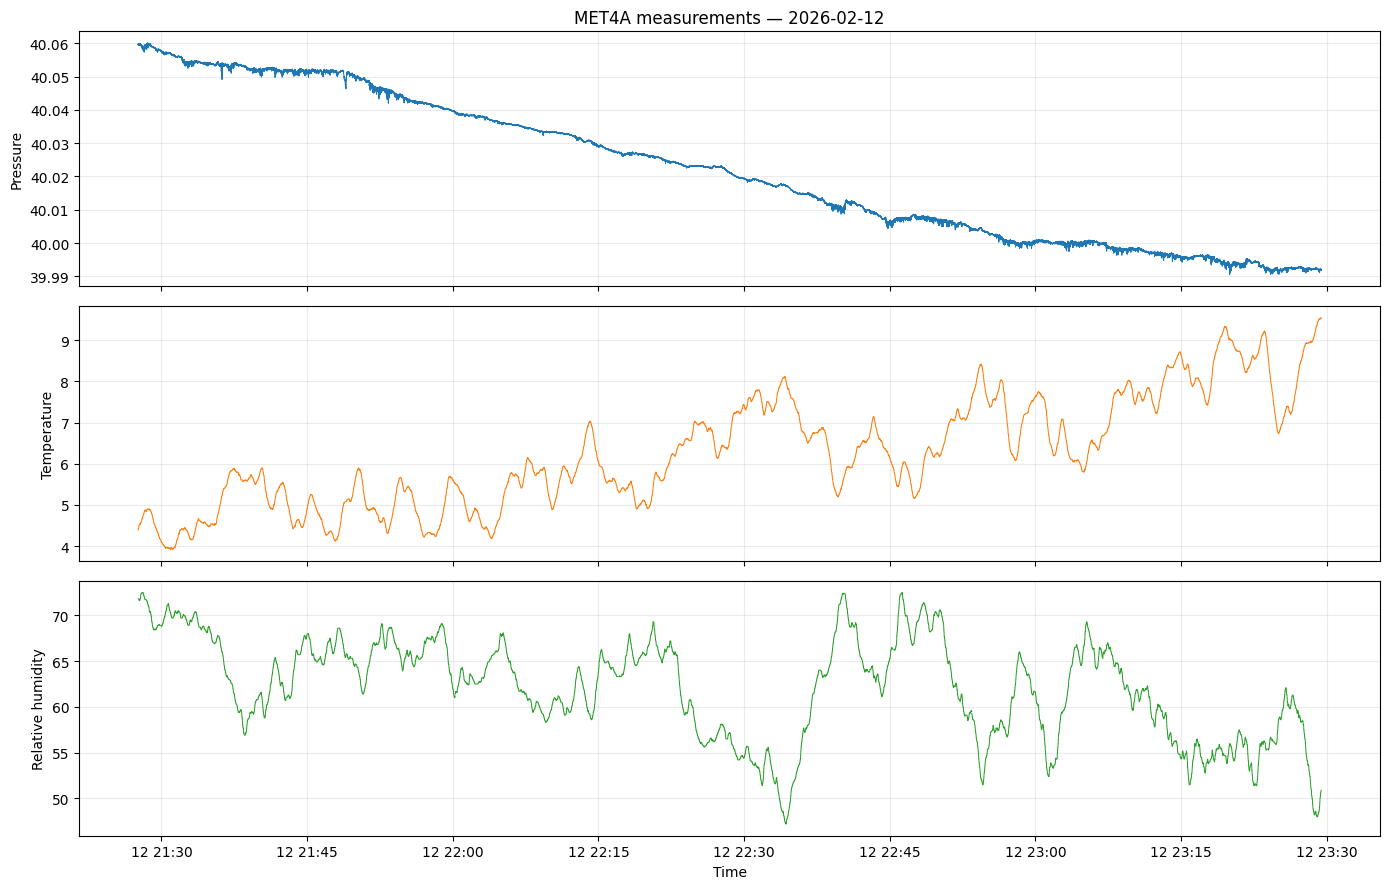

In [ ]:
# Missing rows were stored as (pressure, temp, rh) = (0, 0, 0).
missing = (samples.temp == 0) & (samples.rh == 0)
pressure_plot = np.where(missing, np.nan, samples.pressure)
temp_plot = np.where(missing, np.nan, samples.temp)
rh_plot = np.where(missing, np.nan, samples.rh)

figure, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(
    timestamps,
    pressure_plot,
    linewidth=0.7,
)
axes[0].set_ylabel("Pressure")
axes[0].set_title("MET4A measurements — 2026-02-12")

axes[1].plot(
    timestamps,
    temp_plot,
    color="tab:orange",
    linewidth=0.7,
)
axes[1].set_ylabel("Temperature")

axes[2].plot(
    timestamps,
    rh_plot,
    color="tab:green",
    linewidth=0.7,
)
axes[2].set_ylabel("Relative humidity")
axes[2].set_xlabel("Time")

for axis in axes:
    axis.grid(alpha=0.25)

figure.tight_layout()

plt.show()

## 6. Selecting a smaller time window

Because every row contains an absolute timestamp, we can set a Boolean mask to select any interval.

In [25]:
window_start = samples.time[0] + 60
window_end = window_start + 30
window = samples[(samples.time >= window_start) & (samples.time < window_end)]

print(f"Samples in the 30-second window: {len(window):,}")
window[:5]

Samples in the 30-second window: 1,846


rec.array([(1.77093172e+09, 40.059551, 4.9, 71.2, 40.0591006, 64.),
           (1.77093172e+09, 40.0596  , 4.9, 71.2, 40.0591006, 64.),
           (1.77093172e+09, 40.059662, 4.9, 71.2, 40.0591006, 64.),
           (1.77093172e+09, 40.059644, 4.9, 71.2, 40.0591006, 64.),
           (1.77093172e+09, 40.059621, 4.9, 71.2, 40.0591006, 64.)],
          dtype=[('time', '<f8'), ('pressure', '<f8'), ('temp', '<f8'), ('rh', '<f8'), ('ref_pressure', '<f8'), ('scale_fac', '<f8')])

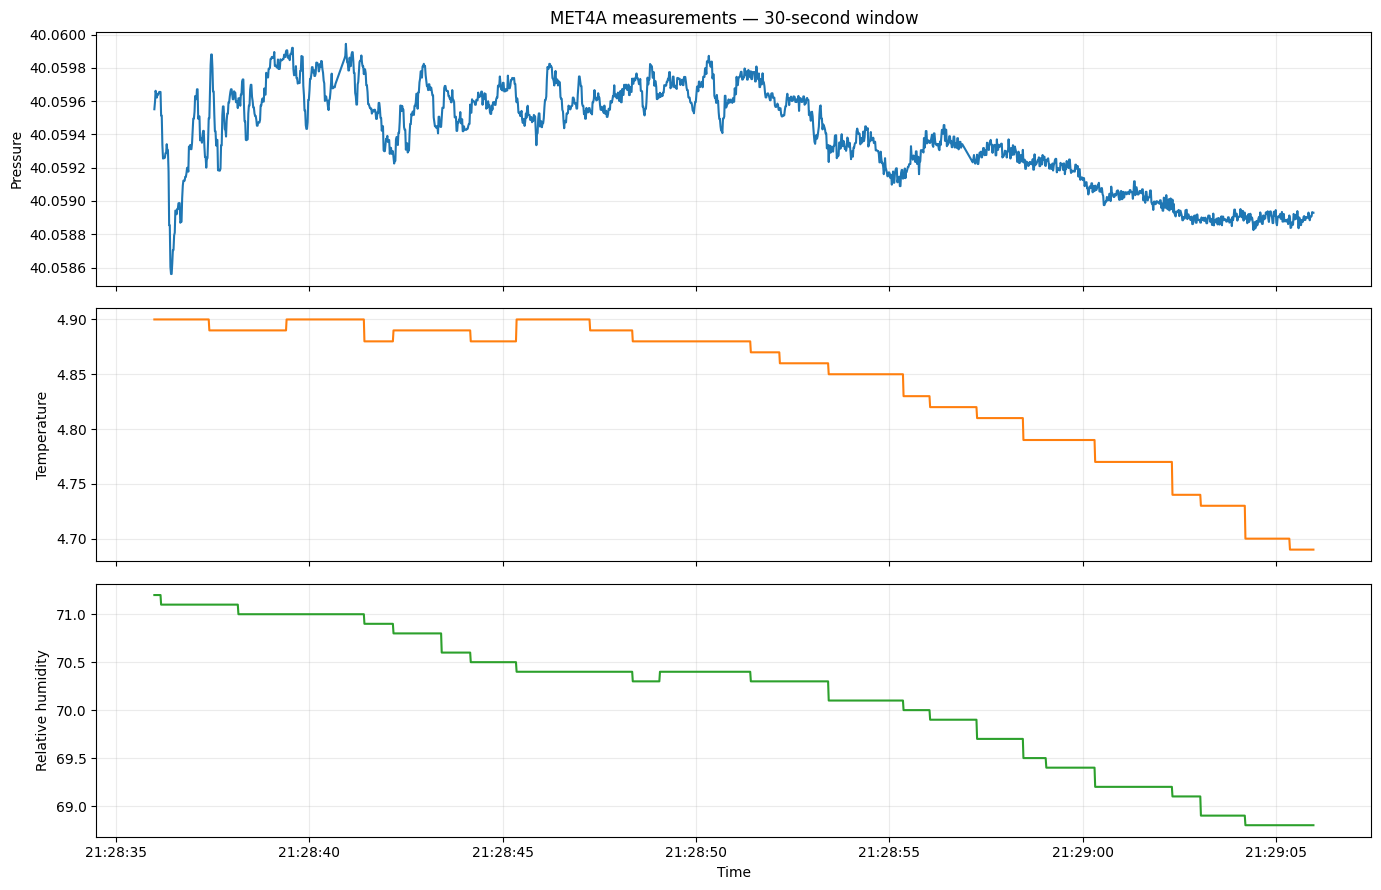

In [26]:
# Pressure is no longer zero after relative-to-absolute conversion, so use
# the unchanged temperature and humidity fields to find missing rows.
missing = (window.temp == 0) & (window.rh == 0)

window_timestamps = (
    window.time * 1_000_000_000
).astype("datetime64[ns]")

pressure_plot = np.where(missing, np.nan, window.pressure)
temp_plot = np.where(missing, np.nan, window.temp)
rh_plot = np.where(missing, np.nan, window.rh)

figure, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(window_timestamps, pressure_plot)
axes[0].set_ylabel("Pressure")
axes[0].set_title("MET4A measurements — 30-second window")

axes[1].plot(window_timestamps, temp_plot, color="tab:orange")
axes[1].set_ylabel("Temperature")

axes[2].plot(window_timestamps, rh_plot, color="tab:green")
axes[2].set_ylabel("Relative humidity")
axes[2].set_xlabel("Time")

for axis in axes:
    axis.grid(alpha=0.25)

figure.tight_layout()
plt.show()